In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Hiển thị số thập phân
pd.set_option('display.float_format', lambda x: '%.4f' % x)

In [3]:
import os
print("Current working directory:", os.getcwd())

Current working directory: d:\MovieLens_Project


In [4]:
import os
print("Files in current folder:", os.listdir('.'))

Files in current folder: ['data', 'notebooks', 'requirements.txt', 'slides']


In [2]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("✅ Đã import pandas và các thư viện cần thiết!")

✅ Đã import pandas và các thư viện cần thiết!


In [3]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("✅ Đã import xong!")

✅ Đã import xong!


In [4]:
# ĐỌC NHANH - CHỈ 1 TRIỆU DÒNG
print("Đang đọc dữ liệu (phiên bản test nhanh)...")

# Chỉ đọc 1 triệu dòng đầu
ratings = pd.read_csv('data/ratings.csv', 
                       nrows=1000000,
                       dtype={'userId': 'int32', 
                              'movieId': 'int32', 
                              'rating': 'float32'})

# movies và tags nhỏ, đọc bình thường
movies = pd.read_csv('data/movies.csv')
tags = pd.read_csv('data/tags.csv')

print(f"\n✅ ratings: {len(ratings):,} dòng")
print(f"✅ movies: {len(movies):,} dòng")  
print(f"✅ tags: {len(tags):,} dòng")

print("\n📊 5 dòng đầu ratings:")
print(ratings.head())

Đang đọc dữ liệu (phiên bản test nhanh)...

✅ ratings: 1,000,000 dòng
✅ movies: 27,278 dòng
✅ tags: 465,564 dòng

📊 5 dòng đầu ratings:
   userId  movieId  rating   timestamp
0       1        2     3.5  1112486027
1       1       29     3.5  1112484676
2       1       32     3.5  1112484819
3       1       47     3.5  1112484727
4       1       50     3.5  1112484580


In [5]:
# CELL 1: IMPORT THƯ VIỆN (luôn chạy cái này trước)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

print("✅ Tất cả thư viện đã sẵn sàng!")

✅ Tất cả thư viện đã sẵn sàng!


In [6]:
# Merge ratings với movies
df = pd.merge(ratings, movies, on='movieId', how='left')
print(f"✅ Sau khi merge: {len(df):,} dòng")
print(f"Các cột: {df.columns.tolist()}")

✅ Sau khi merge: 1,000,000 dòng
Các cột: ['userId', 'movieId', 'rating', 'timestamp', 'title', 'genres']


In [7]:
# Kiểm tra missing values
print("📊 Missing values:")
print(df.isnull().sum())

# Xử lý missing (nếu có)
df['genres'] = df['genres'].fillna('Unknown')
print("\n✅ Đã xử lý missing values")

📊 Missing values:
userId       0
movieId      0
rating       0
timestamp    0
title        0
genres       0
dtype: int64

✅ Đã xử lý missing values


In [8]:
# Kiểm tra duplicates
print(f"Số dòng trước: {len(df):,}")

df = df.drop_duplicates()

print(f"Số dòng sau: {len(df):,}")
print(f"Đã xóa {len(ratings) - len(df):,} dòng trùng lặp")

Số dòng trước: 1,000,000
Số dòng sau: 1,000,000
Đã xóa 0 dòng trùng lặp


In [9]:
# Chuẩn hóa timestamp
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='s')

print("✅ Kiểu dữ liệu sau chuẩn hóa:")
print(df.dtypes)

✅ Kiểu dữ liệu sau chuẩn hóa:
userId               int32
movieId              int32
rating             float32
timestamp    datetime64[s]
title                  str
genres                 str
dtype: object


In [10]:
# Tính giá trị rating trung bình
mean_rating = df['rating'].mean()
print(f"📊 Rating trung bình: {mean_rating:.4f}")

# Tạo dự đoán baseline (tất cả = mean)
y_true = df['rating'].values
y_pred_baseline = [mean_rating] * len(y_true)

# Tính MAE và RMSE
mae = mean_absolute_error(y_true, y_pred_baseline)
rmse = np.sqrt(mean_squared_error(y_true, y_pred_baseline))

print("\n" + "="*50)
print("🎯 KẾT QUẢ BASELINE MODEL (1 triệu dòng test)")
print("="*50)
print(f"MAE  (Sai số tuyệt đối trung bình):  {mae:.4f}")
print(f"RMSE (Căn bậc 2 sai số bình phương): {rmse:.4f}")
print(f"Mean Rating (Giá trị dự đoán):       {mean_rating:.4f}")

📊 Rating trung bình: 3.5268

🎯 KẾT QUẢ BASELINE MODEL (1 triệu dòng test)
MAE  (Sai số tuyệt đối trung bình):  0.8405
RMSE (Căn bậc 2 sai số bình phương): 1.0522
Mean Rating (Giá trị dự đoán):       3.5268


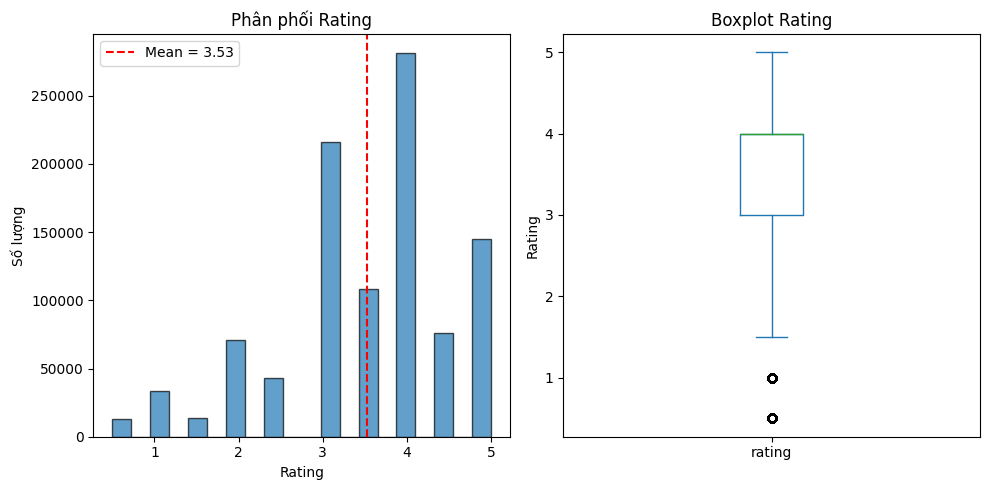

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

# Histogram
plt.subplot(1, 2, 1)
plt.hist(df['rating'], bins=20, edgecolor='black', alpha=0.7)
plt.axvline(mean_rating, color='red', linestyle='--', label=f'Mean = {mean_rating:.2f}')
plt.xlabel('Rating')
plt.ylabel('Số lượng')
plt.title('Phân phối Rating')
plt.legend()

# Boxplot
plt.subplot(1, 2, 2)
df['rating'].plot(kind='box')
plt.title('Boxplot Rating')
plt.ylabel('Rating')

plt.tight_layout()
plt.show()

In [14]:
# LƯU FILE CHO ĐỒNG ĐỘI
import pandas as pd

# 1. Lưu kết quả baseline
results = pd.DataFrame({
    'Model': ['Baseline (Mean)'],
    'MAE': [0.8405],
    'RMSE': [1.0522],
    'Mean_Rating': [3.5268]
})
results.to_csv('baseline_results.csv', index=False)
print("✅ baseline_results.csv")

# 2. Lưu dữ liệu đã xử lý (dạng CSV)
df.to_csv('cleaned_data.csv', index=False)
print("✅ cleaned_data.csv")

# 3. Lưu 1000 dòng mẫu để preview (optional)
df.head(1000).to_csv('sample_data.csv', index=False)
print("✅ sample_data.csv (1000 dòng mẫu)")

print("\n📁 3 file đã được lưu vào thư mục:")
print("   D:\\MovieLens_Project\\")

✅ baseline_results.csv
✅ cleaned_data.csv
✅ sample_data.csv (1000 dòng mẫu)

📁 3 file đã được lưu vào thư mục:
   D:\MovieLens_Project\
